In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
data = pd.read_csv("logs/OMP/RevFftstatandDynTGaussIfft.csv", sep=' ', header=0)

In [8]:
data = pd.read_csv("logs/cuda/finalSetup/times.csv", sep=' ', header=None, names=["N", "real", "user", "sys"])
data.groupby('N').agg(["mean", "std"])*1000

real                user               sys           
          mean        std     mean       std    mean        std
N                                                              
512     186.26  26.864651    15.64  2.422621  153.44  26.580664
1024    193.84   6.845658    20.71  2.854360  155.87   4.885879
2048    213.23   6.795505    36.85  2.475639  159.78   4.678729
4096    302.63   4.628971   106.22  2.258899  180.58   3.779744
8192    676.52   4.164496   397.25  2.384186  262.48   3.063239
16384  2212.66   4.870484  1617.10  4.171815  578.16   3.532590

In [90]:
statDyn["FFTDyn"].unstack()

mean                                                         std  \
N          512       1024      2048      4096      8192      16384     512     
thread                                                                         
2       0.002362  0.009789  0.041574  0.184773  0.801881  3.443225  0.000362   
3       0.001520  0.006514  0.027738  0.124007  0.535800  2.298390  0.000063   
4       0.001284  0.005404  0.020946  0.092897  0.411771  1.783838  0.000155   
5       0.001120  0.004856  0.020782  0.091974  0.405351  1.753805  0.000026   
6       0.001089  0.004729  0.020576  0.093122  0.404520  1.766780  0.000008   
7       0.001078  0.004746  0.020688  0.091374  0.400943  1.752708  0.000064   
8       0.002430  0.005352  0.020603  0.091874  0.400775  1.756345  0.001846   

                                                          
N          1024      2048      4096      8192      16384  
thread                                                    
2       0.000150  0.000268  0.002626  0.006562  0.020914  
3       0.000216  0.000101  0.000584  0.001036  0.003390  
4       0.000676  0.000060  0.000295  0.000795  0.003596  
5       0.000145  0.000388  0.000501  0.005216  0.019866  
6       0.000023  0.000119  0.005683  0.007125  0.024039  
7       0.000199  0.000253  0.001123  0.004320  0.015386  
8       0.001741  0.000233  0.000264  0.001440  0.005808

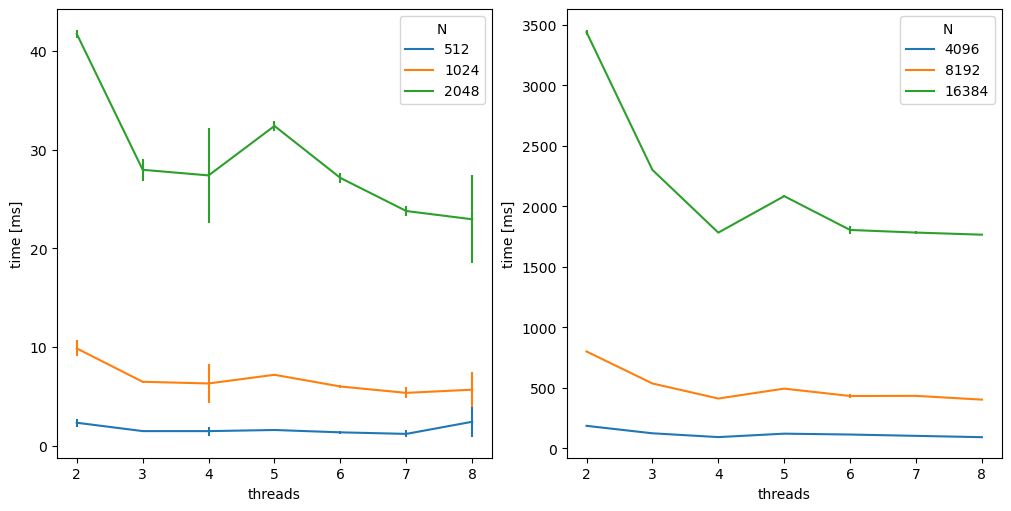

In [99]:
statDyn = data.groupby(["threads", 'N'])[["FFTStat", "FFTDyn"]].agg(["mean", "std"])*1000
fig, ax = plt.subplots(1,2, figsize=(10, 5), layout="constrained")
statDyn["FFTStat"].drop([4096, 8192, 16384], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[0])
statDyn["FFTStat"].drop([512,1024,2048], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[1])
plt.show()